# Phase 2b: Failure Prediction on MetroPT-3

**Question:** will a failure start within the next *N* hours?  **Output:** a risk score between 0 and 1 for every 10-minute window.

**Why this is different from notebook 02:** anomaly detection never used failure labels. Here we train a *supervised* model on the pre-failure periods, so the evaluation has to be extra careful: with only 4 failures it is very easy to fool yourself.

**Method**
1. Build 10-minute window features plus **past-only** rolling features (1 h, 6 h, 24 h)
2. Label each window: does a failure start within the next *N* hours?
3. Validate with **leave-one-failure-out** (train on 3 failures, test on the 4th, repeat)
4. Compare horizons (2, 6, 12, 24 h) and models (Logistic Regression, Random Forest, XGBoost)
5. Pick an alert threshold, measure lead time and false alarms, save the best model

**Needs:** `data/processed/metropt3_labeled.parquet` and `failures.json`.
Install once: `pip install scikit-learn xgboost joblib` (XGBoost is optional, the notebook runs without it).

## 0. Imports and config

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except ImportError:
    HAVE_XGB = False
    print("xgboost not installed - skipping XGBoost (pip install xgboost to enable it)")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROC_DIR = Path("../data/processed")
MODEL_DIR = Path("../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ANALOG = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
DIGITAL = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]

# ---- tunable settings ----
WINDOW = "10min"
HORIZONS = [2, 6, 12, 24]              # prediction horizons to compare (hours)
PRIMARY_HORIZON = 6                    # horizon used for the model comparison and the saved model
BUFFER = pd.Timedelta("24h")           # gap between train and test folds (avoids leakage)
MARGIN = pd.Timedelta("24h")           # alerts up to 24 h before a failure count as early
TARGET_FPR = 0.01                      # alert threshold: 1% of normal windows may exceed it
MIN_CONSEC = 3                         # alert only if 3 windows in a row exceed the threshold

## 1. Load data and failure windows

In [2]:
df = pd.read_parquet(PROC_DIR / "metropt3_labeled.parquet")
with open(PROC_DIR / "failures.json") as f:
    failures = [(pd.Timestamp(x["start"]), pd.Timestamp(x["end"])) for x in json.load(f)]

print("Raw rows:", df.shape, "| range:", df.index.min(), "->", df.index.max())
for i, (s, e) in enumerate(failures, 1):
    print(f"Failure {i}: {s} -> {e}")

Raw rows: (1516948, 17) | range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50
Failure 1: 2020-04-18 00:00:00 -> 2020-04-18 23:59:00
Failure 2: 2020-05-29 23:30:00 -> 2020-05-30 06:00:00
Failure 3: 2020-06-05 10:00:00 -> 2020-06-07 14:30:00
Failure 4: 2020-07-15 14:30:00 -> 2020-07-15 19:00:00


## 2. Window features and past-only rolling features

Same 10-minute windows as notebook 02, then rolling statistics over the **last** 1 h, 6 h and 24 h.
Rolling windows look backwards only: a feature at time *t* never contains information from after *t*.

In [3]:
agg = {c: ["mean", "std", "min", "max"] for c in ANALOG}
agg.update({c: ["mean"] for c in DIGITAL})

feat = df.resample(WINDOW).agg(agg)
feat.columns = [f"{c}_{s}" for c, s in feat.columns]
feat["n_rows"] = df[ANALOG[0]].resample(WINDOW).count()
feat["is_failure"] = df["is_failure"].resample(WINDOW).max()

typical = feat.loc[feat["n_rows"] > 0, "n_rows"].median()
feat = feat[feat["n_rows"] >= 0.5 * typical].copy()
feat = feat.fillna(0)
feat["is_failure"] = feat["is_failure"].astype(int)
print("Windows kept:", len(feat))

Windows kept: 25256


In [4]:
# Sensors the rolling features are built from: analog means, motor-current spread,
# and the compressor duty cycle (a leaking system makes the compressor run more often).
BASE = [f"{c}_mean" for c in ANALOG] + ["Motor_current_std", "COMP_mean"]

# Put the windows on a complete 10-minute grid so that "6 hours ago" means exactly 36 windows.
grid = pd.date_range(feat.index.min(), feat.index.max(), freq=WINDOW)
base_full = feat[BASE].reindex(grid)

MIN_PERIODS = {1: 3, 6: 18, 24: 72}     # need at least ~50% of the windows in the span
means, parts = {}, []
for h in [1, 6, 24]:
    r = base_full.rolling(f"{h}h", min_periods=MIN_PERIODS[h])
    means[h] = r.mean()
    parts.append(means[h].add_suffix(f"__mean{h}h"))
    parts.append(r.std().add_suffix(f"__std{h}h"))
parts.append((base_full - base_full.shift(36)).add_suffix("__delta6h"))   # change over the last 6 h
parts.append((means[1] - means[24]).add_suffix("__dev1h_vs_24h"))         # short-term vs long-term level

R = pd.concat(parts, axis=1).reindex(feat.index)
valid = R.notna().all(axis=1)
print("Windows with a full 24 h history:", int(valid.sum()), "of", len(R))

data = R[valid].copy()
data["is_failure"] = feat.loc[valid, "is_failure"]
FEATS = [c for c in data.columns if c != "is_failure"]
print("Features:", len(FEATS))

Windows with a full 24 h history: 20842 of 25256
Features: 72


## 3. Labels for every horizon

A window ends at `te = start + 10 min`. It is **positive** for horizon *h* if a failure starts between `te` and `te + h`.
Windows that are *inside* a failure are removed: once the failure is underway, "will it fail soon?" is no longer a prediction problem.

In [5]:
te = data.index + pd.Timedelta(WINDOW)
labels = {}
for h in HORIZONS:
    y = np.zeros(len(data), dtype=bool)
    for s, e in failures:
        y |= (te <= s) & (s <= te + pd.Timedelta(hours=h))
    labels[h] = pd.Series(y.astype(int), index=data.index)

# drop windows that are inside a failure
keep = data["is_failure"] == 0
data = data[keep].copy()
labels = {h: y[keep] for h, y in labels.items()}
X = data[FEATS]

summary = pd.DataFrame({
    "positive_windows": {h: int(labels[h].sum()) for h in HORIZONS},
    "share_%": {h: round(100 * labels[h].mean(), 2) for h in HORIZONS},
})
summary.index.name = "horizon_h"
print("Windows after removing failure periods:", len(data))
summary

Windows after removing failure periods: 20389


,positive_windows,share_%
horizon_h,,
2,52,0.26
6,142,0.70
12,250,1.23
24,351,1.72


## 4. Leave-one-failure-out folds

The timeline is cut at the midpoint between neighbouring failures, so every fold contains exactly **one** failure and the normal data around it.
For each fold we train on the other three and test on this one. A 24-hour buffer around the test fold is removed from training, so overlapping rolling windows cannot leak.

In [6]:
starts = np.array([s for s, e in failures], dtype="datetime64[ns]")
mids = starts[:-1] + (starts[1:] - starts[:-1]) / 2
episode = pd.Series(np.searchsorted(mids, data.index.values) + 1, index=data.index)   # 1..4

fold_info = []
for k in sorted(episode.unique()):
    idx_k = data.index[episode == k]
    fold_info.append({"fold": k, "from": idx_k.min(), "to": idx_k.max(), "windows": len(idx_k),
                      "positives(6h)": int(labels[PRIMARY_HORIZON][episode == k].sum())})
pd.DataFrame(fold_info)

,fold,from,to,windows,positives(6h)
0,1,2020-02-01 11:50:00,2020-05-08 23:40:00,9438,37
1,2,2020-05-08 23:50:00,2020-06-02 04:40:00,2148,37
2,3,2020-06-02 04:50:00,2020-06-25 11:50:00,2319,37
3,4,2020-06-25 12:20:00,2020-08-31 20:10:00,6484,31


## 5. Helper functions

In [7]:
def in_failure_zone(index, failures, margin=MARGIN):
    zone = np.zeros(len(index), dtype=bool)
    for s, e in failures:
        zone |= (index >= s - margin) & (index <= e)
    return zone


def lofo_predict(make_model, y):
    # Out-of-fold risk scores: every window is scored by a model that never saw its failure.
    oof = pd.Series(np.nan, index=data.index)
    for k in sorted(episode.unique()):
        test = (episode == k).values
        lo, hi = data.index[test].min(), data.index[test].max()
        buffer_zone = (data.index >= lo - BUFFER) & (data.index <= hi + BUFFER)
        train = ~buffer_zone
        if y[train].sum() == 0 or y[test].sum() == 0:
            continue
        model = make_model(y[train])
        model.fit(X[train], y[train])
        oof[test] = model.predict_proba(X[test])[:, 1]
    return oof


def fold_scores(oof, y):
    rows = []
    for k in sorted(episode.unique()):
        m = ((episode == k) & oof.notna()).values
        if m.sum() == 0 or y[m].sum() == 0:
            continue
        rows.append({"fold": k, "prevalence": y[m].mean(),
                     "pr_auc": average_precision_score(y[m], oof[m]),
                     "roc_auc": roc_auc_score(y[m], oof[m])})
    return pd.DataFrame(rows)


def alert_report(risk, thresh, failures, min_consec=MIN_CONSEC, margin=MARGIN):
    # Event-level view: lead time per failure and number of false-alarm episodes.
    risk = risk.dropna()
    sustained = (risk > thresh).astype(int).rolling(min_consec).min().fillna(0).astype(bool)
    rows = []
    for i, (s, e) in enumerate(failures, 1):
        seg = sustained[(sustained.index >= s - margin) & (sustained.index <= s)]
        hits = seg[seg]
        if len(hits):
            t = hits.index[0]
            rows.append({"failure": i, "first_alert": t, "lead_hours": round((s - t).total_seconds() / 3600, 1)})
        else:
            rows.append({"failure": i, "first_alert": pd.NaT, "lead_hours": np.nan})
    zone = in_failure_zone(risk.index, failures, margin)
    outside = sustained & ~zone
    false_episodes = int((outside & ~outside.shift(fill_value=False)).sum())
    return pd.DataFrame(rows), false_episodes


def pick_threshold(oof, target_fpr=TARGET_FPR):
    # Alert level so that only target_fpr of NORMAL windows (outside every failure zone) exceed it.
    zone = in_failure_zone(oof.index, failures)
    normal = oof[(~zone) & oof.notna()]
    return float(normal.quantile(1 - target_fpr))


def evaluate(oof, y, name):
    fs = fold_scores(oof, y)
    thresh = pick_threshold(oof)
    alerts, false_eps = alert_report(oof, thresh, failures)
    row = {"model": name,
           "mean_pr_auc": fs["pr_auc"].mean(), "min_pr_auc": fs["pr_auc"].min(),
           "mean_roc_auc": fs["roc_auc"].mean(),
           "prevalence": fs["prevalence"].mean(),
           "detected": int(alerts["first_alert"].notna().sum()),
           "median_lead_h": alerts["lead_hours"].median(),
           "false_alarm_episodes": false_eps,
           "threshold": thresh}
    return row, fs, alerts

## 6. Model factories

- **Logistic Regression:** simple, scaled baseline. If a fancy model cannot beat it, the fancy model is not worth it.
- **Random Forest:** handles non-linear patterns, `class_weight` handles the imbalance.
- **XGBoost** (optional): `scale_pos_weight` = negatives / positives.

In [8]:
def make_lr(y_train):
    return make_pipeline(StandardScaler(),
                         LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000))

def make_rf(y_train):
    return RandomForestClassifier(n_estimators=200, min_samples_leaf=5, max_features="sqrt",
                                  class_weight="balanced_subsample", n_jobs=-1,
                                  random_state=RANDOM_STATE)

def make_xgb(y_train):
    pos = max(int((y_train == 1).sum()), 1)
    neg = int((y_train == 0).sum())
    return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, scale_pos_weight=neg / pos, eval_metric="aucpr",
                         n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)

MODELS = {"LogReg": make_lr, "RandomForest": make_rf}
if HAVE_XGB:
    MODELS["XGBoost"] = make_xgb
print("Models:", list(MODELS))

Models: ['LogReg', 'RandomForest', 'XGBoost']


## 7. Which horizon works best? (Random Forest)

Longer horizons give more warning but are harder to predict. This table shows the trade-off.
Compare `mean_pr_auc` with `prevalence`: it should be clearly higher.

In [9]:
rows = []
for h in HORIZONS:
    y = labels[h]
    oof = lofo_predict(make_rf, y)
    row, _, _ = evaluate(oof, y, f"RF {h}h")
    row["horizon_h"] = h
    rows.append(row)
    print(f"done horizon {h}h")

horizon_table = pd.DataFrame(rows).set_index("horizon_h")
horizon_table[["mean_pr_auc", "min_pr_auc", "mean_roc_auc", "prevalence",
               "detected", "median_lead_h", "false_alarm_episodes"]].round(3)

done horizon 2h
done horizon 6h
done horizon 12h
done horizon 24h


,mean_pr_auc,min_pr_auc,mean_roc_auc,prevalence,detected,median_lead_h,false_alarm_episodes
horizon_h,,,,,,,
2,0.004,0.002,0.342,0.004,0,NaN,14
6,0.010,0.003,0.340,0.010,0,NaN,27
12,0.017,0.004,0.248,0.019,0,NaN,18
24,0.024,0.004,0.243,0.030,0,NaN,17


## 8. Compare models at the primary horizon

All models use the same folds. Remember: with 4 folds the numbers are noisy, so look at `min_pr_auc` too (the worst fold), not only the mean.

In [10]:
y = labels[PRIMARY_HORIZON]
results, oofs, fold_tables, alert_tables = [], {}, {}, {}
for name, factory in MODELS.items():
    oof = lofo_predict(factory, y)
    row, fs, alerts = evaluate(oof, y, name)
    results.append(row)
    oofs[name], fold_tables[name], alert_tables[name] = oof, fs, alerts
    print("done", name)

model_table = pd.DataFrame(results).set_index("model")
model_table.round(3)

done LogReg
done RandomForest
done XGBoost


,mean_pr_auc,min_pr_auc,mean_roc_auc,prevalence,detected,median_lead_h,false_alarm_episodes,threshold
model,,,,,,,,
LogReg,0.012,0.002,0.259,0.01,0,NaN,0,1.000
RandomForest,0.010,0.003,0.340,0.01,0,NaN,27,0.379
XGBoost,0.007,0.003,0.245,0.01,0,NaN,21,0.335


In [11]:
# Per-fold detail: does the model work on every failure, or only on some?
for name, fs in fold_tables.items():
    print(f"--- {name}: per-fold scores (fold = the failure that was held out)")
    print(fs.round(3).to_string(index=False))
    print()

--- LogReg: per-fold scores (fold = the failure that was held out)
 fold  prevalence  pr_auc  roc_auc
    1       0.004   0.002    0.004
    2       0.017   0.034    0.762
    3       0.016   0.010    0.256
    4       0.005   0.003    0.013

--- RandomForest: per-fold scores (fold = the failure that was held out)
 fold  prevalence  pr_auc  roc_auc
    1       0.004   0.003    0.183
    2       0.017   0.015    0.383
    3       0.016   0.016    0.312
    4       0.005   0.005    0.483

--- XGBoost: per-fold scores (fold = the failure that was held out)
 fold  prevalence  pr_auc  roc_auc
    1       0.004   0.003    0.180
    2       0.017   0.011    0.297
    3       0.016   0.010    0.236
    4       0.005   0.003    0.269



## 9. Alert timing for the best model

`lead_hours` is how long before the failure started the first sustained alert fired (positive = early warning).
`NaN` means the failure was missed. The threshold lets only 1% of normal windows exceed it.

In [12]:
best_name = model_table["mean_pr_auc"].idxmax()
best_oof = oofs[best_name]
best_thresh = float(model_table.loc[best_name, "threshold"])
print(f"Best model by mean PR-AUC: {best_name}   |   threshold = {best_thresh:.3f}")
print()
print(alert_tables[best_name].to_string(index=False))
print("False-alarm episodes outside failure zones:", int(model_table.loc[best_name, "false_alarm_episodes"]))

Best model by mean PR-AUC: LogReg   |   threshold = 1.000

 failure first_alert  lead_hours
       1         NaT         NaN
       2         NaT         NaN
       3         NaT         NaN
       4         NaT         NaN
False-alarm episodes outside failure zones: 0


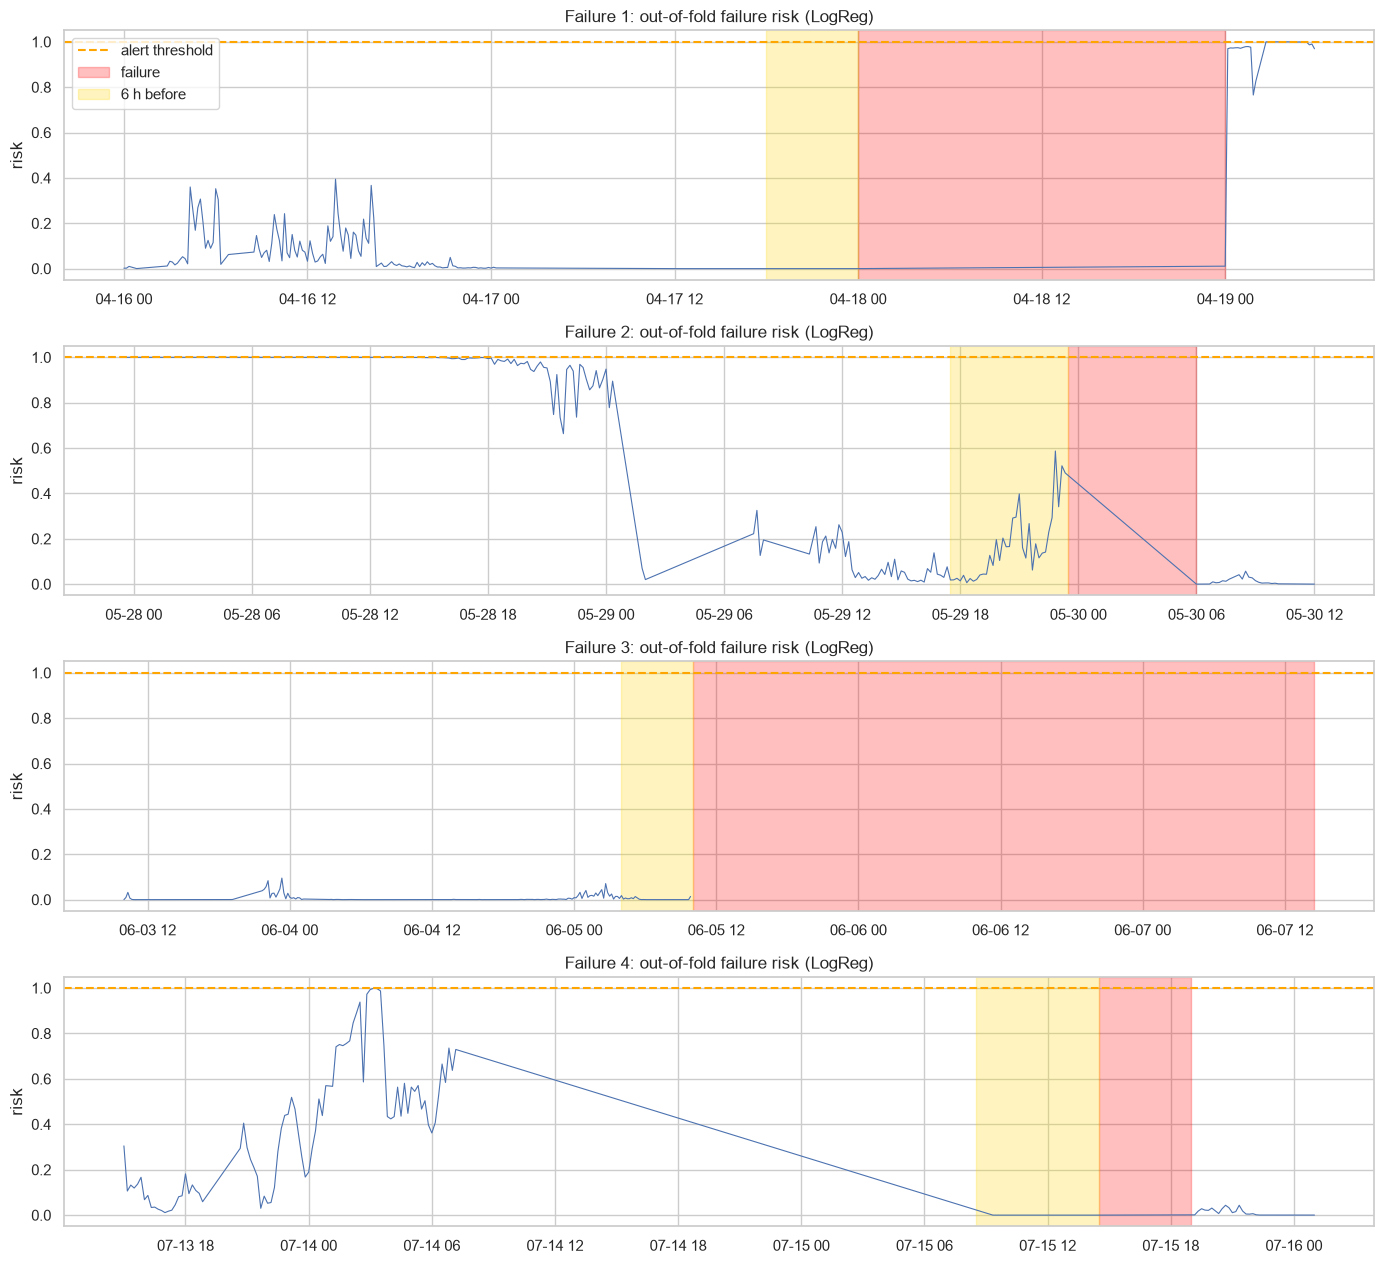

In [13]:
fig, axes = plt.subplots(len(failures), 1, figsize=(14, 3.2 * len(failures)))
axes = np.atleast_1d(axes)
for i, (ax, (s, e)) in enumerate(zip(axes, failures), 1):
    seg = best_oof[(best_oof.index >= s - pd.Timedelta("48h")) & (best_oof.index <= e + pd.Timedelta("6h"))].dropna()
    ax.plot(seg.index, seg.values, lw=0.8)
    ax.axhline(best_thresh, color="orange", ls="--", label="alert threshold")
    ax.axvspan(s, e, color="red", alpha=0.25, label="failure")
    ax.axvspan(s - pd.Timedelta(hours=PRIMARY_HORIZON), s, color="gold", alpha=0.25, label=f"{PRIMARY_HORIZON} h before")
    ax.set_title(f"Failure {i}: out-of-fold failure risk ({best_name})")
    ax.set_ylabel("risk")
    if i == 1:
        ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

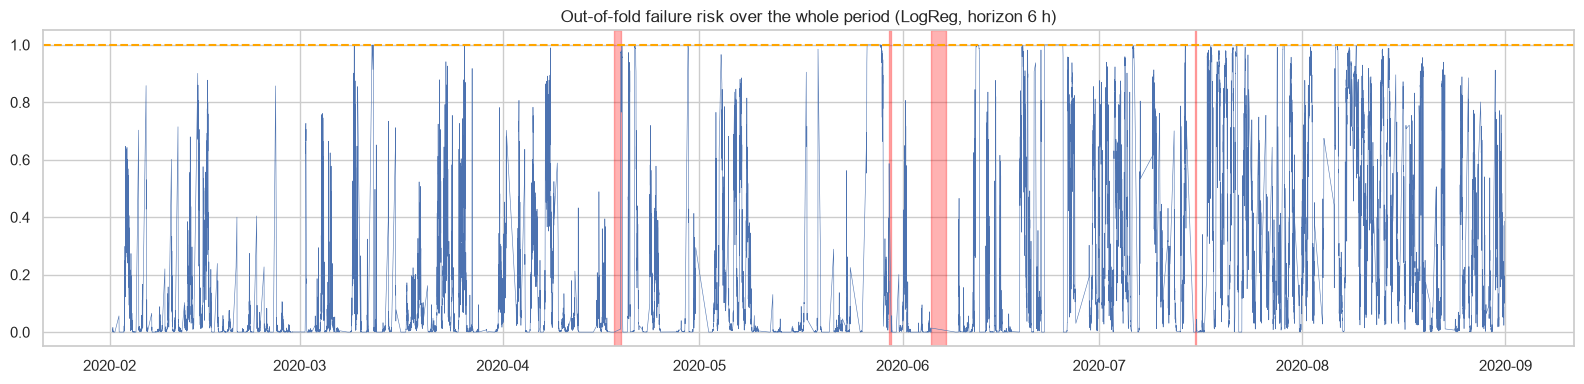

In [14]:
# Whole timeline
s_all = best_oof.dropna()
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(s_all.index, s_all.values, lw=0.4)
ax.axhline(best_thresh, color="orange", ls="--")
for i, (s, e) in enumerate(failures):
    ax.axvspan(s, e, color="red", alpha=0.3)
ax.set_title(f"Out-of-fold failure risk over the whole period ({best_name}, horizon {PRIMARY_HORIZON} h)")
plt.tight_layout()
plt.show()

## 10. What does the model look at? (feature importance)

Fit once on all data (excluding failure periods) just to inspect it. Gini importances are only a rough guide, but they should agree with what you saw in notebook 01: sensors that shifted before failures should rank high.

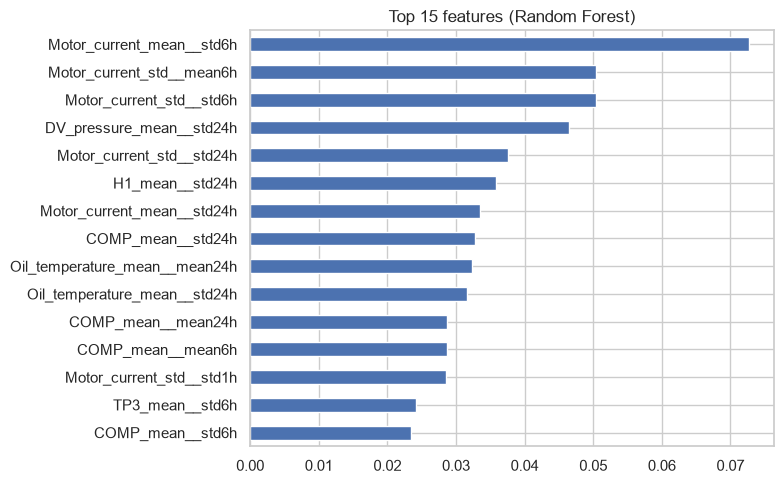

Motor_current_mean__std6h        0.0727
Motor_current_std__mean6h        0.0504
Motor_current_std__std6h         0.0504
DV_pressure_mean__std24h         0.0465
Motor_current_std__std24h        0.0376
H1_mean__std24h                  0.0358
Motor_current_mean__std24h       0.0335
COMP_mean__std24h                0.0328
Oil_temperature_mean__mean24h    0.0323
Oil_temperature_mean__std24h     0.0317
COMP_mean__mean24h               0.0287
COMP_mean__mean6h                0.0287
Motor_current_std__std1h         0.0286
TP3_mean__std6h                  0.0242
COMP_mean__std6h                 0.0234
dtype: float64

In [15]:
rf_inspect = make_rf(y).fit(X, y)
imp = pd.Series(rf_inspect.feature_importances_, index=FEATS).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp[::-1].plot.barh()
plt.title("Top 15 features (Random Forest)")
plt.tight_layout()
plt.show()
imp.round(4)

## 11. Save the best model

Refit on **all** data (excluding failure periods) and save with its config. The threshold comes from the out-of-fold scores above.

In [16]:
final_model = MODELS[best_name](y).fit(X, y)
joblib.dump(final_model, MODEL_DIR / "failure_model.joblib")

config = {
    "model": best_name,
    "horizon_hours": PRIMARY_HORIZON,
    "window": WINDOW,
    "base_columns": BASE,
    "features": FEATS,
    "rolling_hours": [1, 6, 24],
    "min_periods": MIN_PERIODS,
    "threshold": best_thresh,
    "target_false_positive_rate": TARGET_FPR,
    "min_consecutive_windows": MIN_CONSEC,
}
with open(MODEL_DIR / "failure_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:", sorted(p.name for p in MODEL_DIR.iterdir()))

Saved: ['anomaly_config.json', 'failure_config.json', 'failure_model.joblib', 'isolation_forest.joblib', 'lstm_autoencoder.pt', 'scaler.joblib']


## 12. Notes (fill these in)

- Did the best model beat the prevalence clearly (PR-AUC vs `prevalence`)? In every fold or only some? ...
- Which horizon gave the best balance between warning time and accuracy? ...
- Did Logistic Regression do almost as well as the complex models? ...
- Which failures were detected, with how many hours of lead time? Which were missed, and why do you think so? ...
- How many false-alarm episodes? ...
- Which features matter most, and does that agree with notebook 01 and with the anomaly notebook? ...

**Honest limits to mention in the README:** only 4 failures, one machine, thresholds chosen from the same out-of-fold scores that are evaluated (a small optimism), possible sensor drift over the months.